## load data

In [1]:
# Cell 1: load both sheets, parsing the datetime column
import pandas as pd

xls = pd.read_excel(
    'ParleysRWIS_20211101-20230430.xlsx',
    sheet_name=['RwisAtmosphericData', 'RwisSurfaceData'],
    parse_dates=['SampleTime'],    # ← ensure this column is parsed as full datetime
    engine='openpyxl'
)

df1 = xls['RwisAtmosphericData']
df2 = xls['RwisSurfaceData']

# quick check
print(df1['SampleTime'].dtype, df1['SampleTime'].head())
print(df2['SampleTime'].dtype, df2['SampleTime'].head())




datetime64[ns] 0   2021-11-01 00:00:00
1   2021-11-01 00:10:00
2   2021-11-01 00:20:00
3   2021-11-01 00:30:00
4   2021-11-01 00:40:00
Name: SampleTime, dtype: datetime64[ns]
datetime64[ns] 0   2021-11-01 00:00:00
1   2021-11-01 00:10:00
2   2021-11-01 00:20:00
3   2021-11-01 00:30:00
4   2021-11-01 00:40:00
Name: SampleTime, dtype: datetime64[ns]


In [2]:
# 假设 df1 和 df2 都有 'SampleTime' 和 'RwisControllerIntId' 这两列

# 1) 确保这两列的数据类型一致
df1['SampleTime'] = pd.to_datetime(df1['SampleTime'])
df2['SampleTime'] = pd.to_datetime(df2['SampleTime'])

# 如果 RwisControllerIntId 是数字或字符串，要保证两表类型相同：
df1['RwisControllerIntId'] = df1['RwisControllerIntId'].astype(str)
df2['RwisControllerIntId'] = df2['RwisControllerIntId'].astype(str)

# 2) 基于两个键合并
df_merged = pd.merge(
    df1,
    df2,
    on=['SampleTime', 'RwisControllerIntId'],
    how='inner',
    suffixes=('_atm','_surf')
)

# 3) 检查结果
print(df_merged[['SampleTime','RwisControllerIntId']].head())
print("合并后行数：", len(df_merged))



           SampleTime RwisControllerIntId
0 2021-11-01 00:00:00                  26
1 2021-11-01 00:10:00                  26
2 2021-11-01 00:20:00                  26
3 2021-11-01 00:30:00                  26
4 2021-11-01 00:40:00                  26
合并后行数： 510142


In [3]:
# show all rows and all columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# if you also want to see full cell contents without truncation:
pd.set_option('display.max_colwidth', None)
summary = pd.DataFrame({
    'dtype': df_merged.dtypes,
    'n_unique': df_merged.nunique(),
    'n_missing': df_merged.isna().sum(),
    'pct_missing': df_merged.isna().mean() * 100
})
summary

,dtype,n_unique,n_missing,pct_missing
RwisAtmoEquipmentIntId,int64,4,0,0.000000
SampleTime,datetime64[ns],151109,0,0.000000
RwisControllerIntId,object,4,0,0.000000
AirTemp_atm,float64,7464,988,0.193672
RelativeHumidity_atm,float64,7502,1523,0.298544
DewPoint_atm,float64,7166,0,0.000000
WindDirection,float64,10296,5,0.000980
WindSpeedAverage,float64,3004,5,0.000980
WindSpeedGust,float64,287,0,0.000000
WindSpeedGustTimestamp,datetime64[ns],507342,0,0.000000


## drop some useless columns

In [4]:
cols_to_drop = ['Pressure', 'SnowIntervalDepth', 'PrecipitationIntervalAmount','PrecipitationAmount',
                'RoadStatusText','iceCurCondIndex','iceAvgCondIndex','iceCurCondCode','iceAvgCondCode',
               'iceCurFricIndex','iceAvgFricIndex','iceCurFricCode','iceAvgFricCode','iceGrip','iceXValue',
               'iceYValue','iceYXRatio','iceLens','SurfaceSensorError','SurfaceSalinity','SurfaceFreezePoint','RoadStatus',
               'RoadStatus','RoadTemp','iceRoadTemp','RwisAtmoEquipmentIntId','WindSpeedGustTimestamp',
               'RwisSurfaceEquipmentIntId']  # ← put your column names here
df_merged = df_merged.drop(columns=cols_to_drop)

# verify they’re gone
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 510142 entries, 0 to 510141
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              510142 non-null  datetime64[ns]
 1   RwisControllerIntId     510142 non-null  object        
 2   AirTemp_atm             509154 non-null  float64       
 3   RelativeHumidity_atm    508619 non-null  float64       
 4   DewPoint_atm            510142 non-null  float64       
 5   WindDirection           510137 non-null  float64       
 6   WindSpeedAverage        510137 non-null  float64       
 7   WindSpeedGust           510142 non-null  float64       
 8   PrecipitationIntensity  45706 non-null   object        
 9   SnowDepth               115089 non-null  float64       
 10  SolarRadiation          434049 non-null  float64       
 11  Visibility              506152 non-null  float64       
 12  PrecipitationType       508441

In [5]:
df_merged.describe().T

,count,mean,std,min,25%,50%,75%,max
AirTemp_atm,509154.0,42.510021,20.853891,-148.000000,27.520000,37.939999,58.000000,165.199997
RelativeHumidity_atm,508619.0,57.492431,23.361791,5.000000,38.410000,57.230000,76.599998,100.000000
DewPoint_atm,510142.0,25.692230,13.623525,-148.000000,17.010000,24.879999,33.299999,71.089996
WindDirection,510137.0,169.411153,93.452026,0.000000,86.800003,139.699997,262.200012,360.000000
WindSpeedAverage,510137.0,6.524611,4.117160,0.000000,3.590000,5.900000,8.750000,39.080002
WindSpeedGust,510142.0,10.958354,6.396704,0.000000,6.580000,9.860000,13.810000,75.190002
SnowDepth,115089.0,12.834478,14.421847,0.000000,0.150000,8.690000,19.840000,47.349998
SolarRadiation,434049.0,153.513885,264.606891,-0.010000,0.000000,0.570000,189.199997,1280.000000
Visibility,506152.0,9.441039,1.976668,0.000000,10.000000,10.000000,10.000000,10.000000
BatteryVoltage,510142.0,12.667152,0.660398,0.000000,12.060000,12.560000,13.260000,14.450000


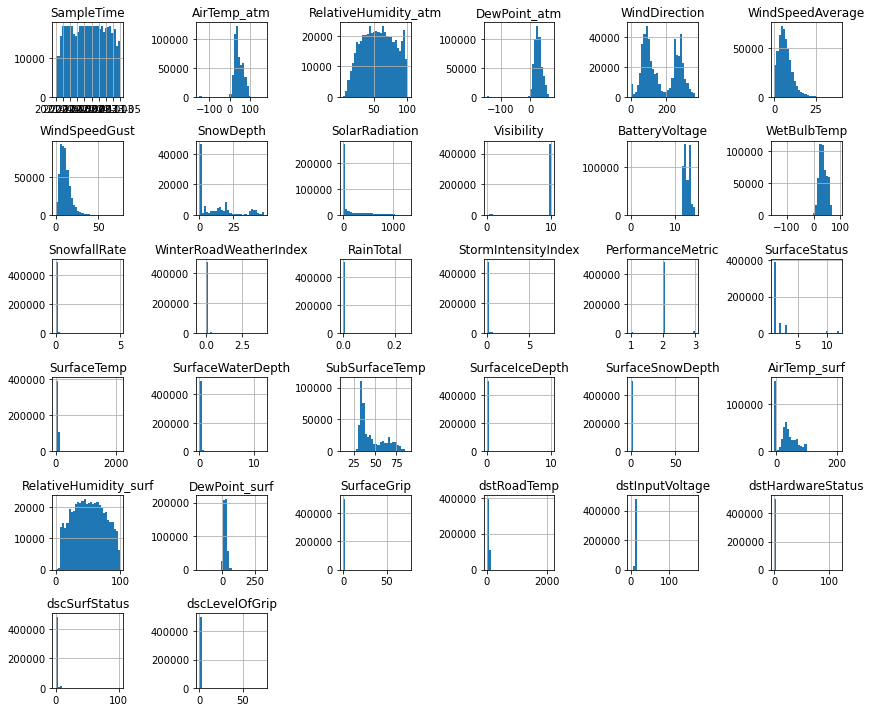

In [6]:
# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

df_merged.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

In [7]:
# show all rows and all columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# if you also want to see full cell contents without truncation:
pd.set_option('display.max_colwidth', None)
summary = pd.DataFrame({
    'dtype': df_merged.dtypes,
    'n_unique': df_merged.nunique(),
    'n_missing': df_merged.isna().sum(),
    'pct_missing': df_merged.isna().mean() * 100
})
summary

,dtype,n_unique,n_missing,pct_missing
SampleTime,datetime64[ns],151109,0,0.000000
RwisControllerIntId,object,4,0,0.000000
AirTemp_atm,float64,7464,988,0.193672
RelativeHumidity_atm,float64,7502,1523,0.298544
DewPoint_atm,float64,7166,0,0.000000
WindDirection,float64,10296,5,0.000980
WindSpeedAverage,float64,3004,5,0.000980
WindSpeedGust,float64,287,0,0.000000
PrecipitationIntensity,object,4,464436,91.040534
SnowDepth,float64,4437,395053,77.439811


In [8]:
df_merged.head(5)

,SampleTime,RwisControllerIntId,AirTemp_atm,RelativeHumidity_atm,DewPoint_atm,WindDirection,WindSpeedAverage,WindSpeedGust,PrecipitationIntensity,SnowDepth,SolarRadiation,Visibility,PrecipitationType,BatteryVoltage,WetBulbTemp,SnowfallRate,WinterRoadWeatherIndex,RainTotal,StormIntensityIndex,PerformanceMetric,SurfaceStatus,SurfaceTemp,SurfaceWaterDepth,SubSurfaceTemp,SurfaceIceDepth,SurfaceSnowDepth,AirTemp_surf,RelativeHumidity_surf,DewPoint_surf,SurfaceStatusText,SurfaceGrip,dstRoadTemp,dstInputVoltage,dstHardwareStatus,dscSurfStatus,dscRoadStatusText,dscLevelOfGrip
0,2021-11-01 00:00:00,26,54.060001,51.349998,36.540001,82.699997,11.33,17.760000,NaN,NaN,NaN,10.0,No,12.09,45.730000,0.0,0.0,0.0,0.0,2.0,1.0,51.980000,0.0,54.849998,0.0,0.0,52.880001,52.099998,35.959999,Dry,0.82,51.980000,11.8,0.0,1.0,Dry,0.82
1,2021-11-01 00:10:00,26,53.759998,52.029999,36.590000,98.000000,8.96,18.629999,NaN,NaN,NaN,10.0,No,12.09,45.590000,0.0,0.0,0.0,0.0,2.0,1.0,52.700001,0.0,54.860001,0.0,0.0,52.160000,53.500000,35.779999,Dry,0.82,52.700001,11.8,0.0,1.0,Dry,0.82
2,2021-11-01 00:20:00,26,54.470001,53.470001,37.939999,334.399994,6.84,13.370000,NaN,NaN,NaN,10.0,No,12.08,46.450001,0.0,0.0,0.0,0.0,2.0,1.0,54.320000,0.0,54.860001,0.0,0.0,52.520000,53.400002,36.139999,Dry,0.82,54.320000,11.8,0.0,1.0,Dry,0.82
3,2021-11-01 00:30:00,26,53.610001,53.380001,37.090000,280.600006,2.18,8.550000,NaN,NaN,NaN,10.0,No,12.09,45.720001,0.0,0.0,0.0,0.0,2.0,1.0,52.990002,0.0,54.860001,0.0,0.0,53.060001,53.400002,36.680000,Dry,0.82,52.990002,11.8,0.0,1.0,Dry,0.82
4,2021-11-01 00:40:00,26,53.119999,55.910000,37.820000,20.840000,5.66,10.520000,Light,NaN,NaN,10.0,Yes,12.08,45.759998,0.0,0.0,0.0,0.0,2.0,2.0,52.340000,0.0,54.860001,0.0,0.0,51.799999,55.799999,36.500000,Damp,0.81,52.340000,11.8,0.0,2.0,Damp,0.81


In [9]:
df_merged1 = df_merged.sort_values(
    ['RwisControllerIntId','SampleTime']
).reset_index(drop=True)

# Cell 2: 计算同一设备内相邻记录的时间差
df_merged['time_diff'] = df_merged.groupby('RwisControllerIntId')['SampleTime'].diff()

In [10]:
df_merged.head()

,SampleTime,RwisControllerIntId,AirTemp_atm,RelativeHumidity_atm,DewPoint_atm,WindDirection,WindSpeedAverage,WindSpeedGust,PrecipitationIntensity,SnowDepth,SolarRadiation,Visibility,PrecipitationType,BatteryVoltage,WetBulbTemp,SnowfallRate,WinterRoadWeatherIndex,RainTotal,StormIntensityIndex,PerformanceMetric,SurfaceStatus,SurfaceTemp,SurfaceWaterDepth,SubSurfaceTemp,SurfaceIceDepth,SurfaceSnowDepth,AirTemp_surf,RelativeHumidity_surf,DewPoint_surf,SurfaceStatusText,SurfaceGrip,dstRoadTemp,dstInputVoltage,dstHardwareStatus,dscSurfStatus,dscRoadStatusText,dscLevelOfGrip,time_diff
0,2021-11-01 00:00:00,26,54.060001,51.349998,36.540001,82.699997,11.33,17.760000,NaN,NaN,NaN,10.0,No,12.09,45.730000,0.0,0.0,0.0,0.0,2.0,1.0,51.980000,0.0,54.849998,0.0,0.0,52.880001,52.099998,35.959999,Dry,0.82,51.980000,11.8,0.0,1.0,Dry,0.82,NaT
1,2021-11-01 00:10:00,26,53.759998,52.029999,36.590000,98.000000,8.96,18.629999,NaN,NaN,NaN,10.0,No,12.09,45.590000,0.0,0.0,0.0,0.0,2.0,1.0,52.700001,0.0,54.860001,0.0,0.0,52.160000,53.500000,35.779999,Dry,0.82,52.700001,11.8,0.0,1.0,Dry,0.82,0 days 00:10:00
2,2021-11-01 00:20:00,26,54.470001,53.470001,37.939999,334.399994,6.84,13.370000,NaN,NaN,NaN,10.0,No,12.08,46.450001,0.0,0.0,0.0,0.0,2.0,1.0,54.320000,0.0,54.860001,0.0,0.0,52.520000,53.400002,36.139999,Dry,0.82,54.320000,11.8,0.0,1.0,Dry,0.82,0 days 00:10:00
3,2021-11-01 00:30:00,26,53.610001,53.380001,37.090000,280.600006,2.18,8.550000,NaN,NaN,NaN,10.0,No,12.09,45.720001,0.0,0.0,0.0,0.0,2.0,1.0,52.990002,0.0,54.860001,0.0,0.0,53.060001,53.400002,36.680000,Dry,0.82,52.990002,11.8,0.0,1.0,Dry,0.82,0 days 00:10:00
4,2021-11-01 00:40:00,26,53.119999,55.910000,37.820000,20.840000,5.66,10.520000,Light,NaN,NaN,10.0,Yes,12.08,45.759998,0.0,0.0,0.0,0.0,2.0,2.0,52.340000,0.0,54.860001,0.0,0.0,51.799999,55.799999,36.500000,Damp,0.81,52.340000,11.8,0.0,2.0,Damp,0.81,0 days 00:10:00


In [11]:
# Cell 1：重算一遍，确保 time_diff 是按设备分组计算的
df_merged = df_merged.sort_values(['RwisControllerIntId','SampleTime']).reset_index(drop=True)
df_merged['time_diff'] = df_merged.groupby('RwisControllerIntId')['SampleTime'].diff()

# Cell 2：统计各设备下不同 time_diff 出现次数
dist_per_id = (
    df_merged
    .groupby(['RwisControllerIntId','time_diff'])
    .size()
    .sort_index()
)

# Cell 3：以 Series 形式查看（MultiIndex）
dist_per_id


RwisControllerIntId  time_diff       
158                  0 days 00:05:00     133095
                     0 days 00:10:00       6118
                     0 days 00:15:00          1
                     0 days 01:05:00          2
                     6 days 22:50:00          1
                     8 days 15:30:00          1
                     25 days 16:15:00         1
26                   0 days 00:10:00      69872
                     0 days 00:20:00          2
                     0 days 01:00:00          1
                     0 days 01:10:00          1
                     0 days 01:20:00          1
                     0 days 03:00:00          1
                     0 days 03:50:00          1
                     15 days 14:50:00         1
                     44 days 16:40:00         1
27                   0 days 00:05:00     144603
                     0 days 00:10:00       6120
                     0 days 00:15:00          1
                     0 days 01:00:00          2
  

In [12]:
# 定义合法的间隔
valid_intervals = [pd.Timedelta(minutes=5), pd.Timedelta(minutes=10)]

# 在原始 df_merged 上过滤
mask = df_merged['time_diff'].isin(valid_intervals)
df_valid = df_merged[mask]

# 然后按设备和间隔统计分布
dist_per_id = (
    df_valid
    .groupby(['RwisControllerIntId','time_diff'])
    .size()
    .sort_index()
)
dist_per_id



RwisControllerIntId  time_diff      
158                  0 days 00:05:00    133095
                     0 days 00:10:00      6118
26                   0 days 00:10:00     69872
27                   0 days 00:05:00    144603
                     0 days 00:10:00      6120
29                   0 days 00:05:00    144181
                     0 days 00:10:00      6118
dtype: int64

In [13]:
import pandas as pd

# 1) 首先，先在 df_merged 上计算一次原始的 time_diff
df = df_merged.sort_values(['RwisControllerIntId','SampleTime']).reset_index(drop=True)
df['time_diff'] = df.groupby('RwisControllerIntId')['SampleTime'].diff()

# 2) 定义“要删掉”的 5 分钟行：time_diff==5min 且 SampleTime.minute % 10 == 5
mask_drop5 = (
    (df['time_diff'] == pd.Timedelta(minutes=5)) &
    (df['SampleTime'].dt.minute % 10 == 5)
)

# 3) 在原始 df 上先去掉这部分行
df2 = df[~mask_drop5].reset_index(drop=True)

# 4) 再次按设备排序并重新计算 time_diff
df2 = df2.sort_values(['RwisControllerIntId','SampleTime']).reset_index(drop=True)
df2['time_diff'] = df2.groupby('RwisControllerIntId')['SampleTime'].diff()

# 5) 最后，只保留 diff == 10 分钟 的记录
df10 = df2[df2['time_diff'] == pd.Timedelta(minutes=10)].reset_index(drop=True)

# 6) 检查分布
print(df10['time_diff'].value_counts())



0 days 00:10:00    299144
Name: time_diff, dtype: int64


In [14]:
# 然后按设备和间隔统计分布
dist_per_id = (
    df10
    .groupby(['RwisControllerIntId','time_diff'])
    .size()
    .sort_index()
)
dist_per_id

RwisControllerIntId  time_diff      
158                  0 days 00:10:00    72660
26                   0 days 00:10:00    69872
27                   0 days 00:10:00    78413
29                   0 days 00:10:00    78199
dtype: int64

In [15]:
cols_to_drop = ['time_diff','dscLevelOfGrip']  # ← put your column names here
df10 = df10.drop(columns=cols_to_drop)

# verify they’re gone
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299144 entries, 0 to 299143
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              299144 non-null  datetime64[ns]
 1   RwisControllerIntId     299144 non-null  object        
 2   AirTemp_atm             298617 non-null  float64       
 3   RelativeHumidity_atm    298347 non-null  float64       
 4   DewPoint_atm            299144 non-null  float64       
 5   WindDirection           299142 non-null  float64       
 6   WindSpeedAverage        299142 non-null  float64       
 7   WindSpeedGust           299144 non-null  float64       
 8   PrecipitationIntensity  26166 non-null   object        
 9   SnowDepth               60170 non-null   float64       
 10  SolarRadiation          223732 non-null  float64       
 11  Visibility              296786 non-null  float64       
 12  PrecipitationType       298223

In [16]:
# remove the nan value or missing in y
df10 = df10.dropna(subset=['SurfaceGrip']).reset_index(drop=True)

(array([1.00000e+00, 0.00000e+00, 2.00000e+00, 1.80000e+01, 2.80000e+02,
        3.93000e+02, 3.23000e+02, 1.71000e+02, 2.63000e+02, 2.52000e+02,
        2.10000e+02, 1.99000e+02, 2.17000e+02, 1.97000e+02, 2.07000e+02,
        1.54000e+02, 2.31000e+02, 2.25000e+02, 2.75000e+02, 4.49000e+02,
        9.76000e+02, 1.03600e+03, 1.19400e+03, 3.14900e+03, 6.03500e+03,
        9.53100e+03, 1.60320e+04, 4.10050e+04, 2.08726e+05, 1.00000e+00]),
 array([0.01      , 0.03866667, 0.06733333, 0.096     , 0.12466667,
        0.15333333, 0.182     , 0.21066667, 0.23933333, 0.268     ,
        0.29666667, 0.32533333, 0.354     , 0.38266667, 0.41133334,
        0.44      , 0.46866667, 0.49733334, 0.526     , 0.55466667,
        0.58333334, 0.612     , 0.64066667, 0.66933334, 0.698     ,
        0.72666667, 0.75533334, 0.784     , 0.81266667, 0.84133334,
        0.87      ]),
 <BarContainer object of 30 artists>)

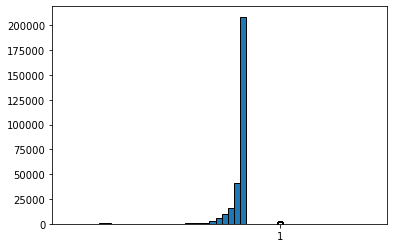

In [17]:
# remove not normal value

# 过滤 SurfaceGrip 不在 [0,1] 区间的行
df10 = df10[
    (df10['SurfaceGrip'] >= 0) &
    (df10['SurfaceGrip'] < 1)
].reset_index(drop=True)

# 验证剩余的数据统计
df10['SurfaceGrip'].describe()

plt.boxplot(df10['SurfaceGrip'])

plt.hist(df10['SurfaceGrip'], bins=30, edgecolor='black')

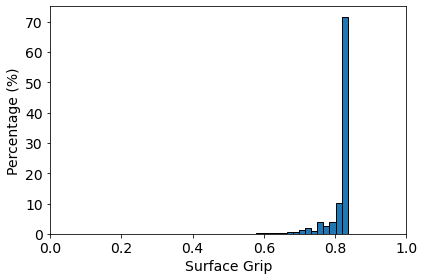

In [18]:
import matplotlib.pyplot as plt

# Plot histogram with percentages and x-limits
plt.figure()

# Plot histogram, get counts and bin edges
counts, bins, patches = plt.hist(
    df10['SurfaceGrip'], 
    bins=50, 
    edgecolor='black', 
    weights=[100/len(df10)] * len(df10)  # Convert counts to percentage
)

# Labeling
plt.xlabel('Surface Grip',fontsize=14)
plt.ylabel('Percentage (%)',fontsize=14)
# plt.title('SurfaceGrip Distribution (0–1)')
plt.xlim(0, 1)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig('surface_grip_distribution.png', dpi=300)



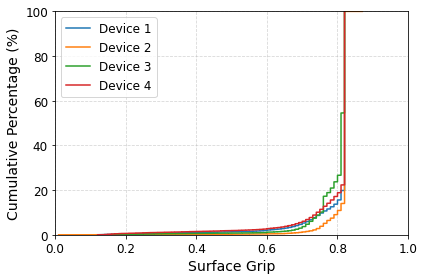

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

device_ids = sorted(df10['RwisControllerIntId'].unique())

for i, device_id in enumerate(device_ids, start=1):
    grip_values = df10[df10['RwisControllerIntId'] == device_id]['SurfaceGrip'].sort_values().values
    cdf = np.arange(1, len(grip_values) + 1) / len(grip_values) * 100  # 百分比形式

    plt.plot(grip_values, cdf, label=f'Device {i}')

# 图像设置
plt.xlabel('Surface Grip', fontsize=14)
plt.ylabel('Cumulative Percentage (%)', fontsize=14)
plt.xlim(0, 1)
plt.ylim(0, 100)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 保存图像
plt.savefig('surface_grip_cdf_by_device.png', dpi=300)
plt.show()


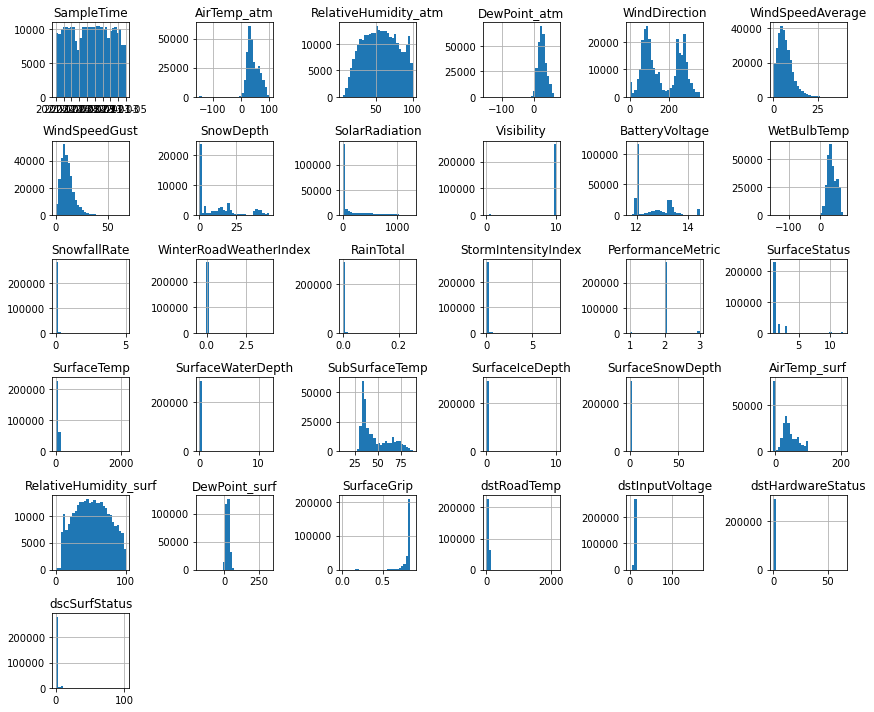

In [20]:
# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

df10.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

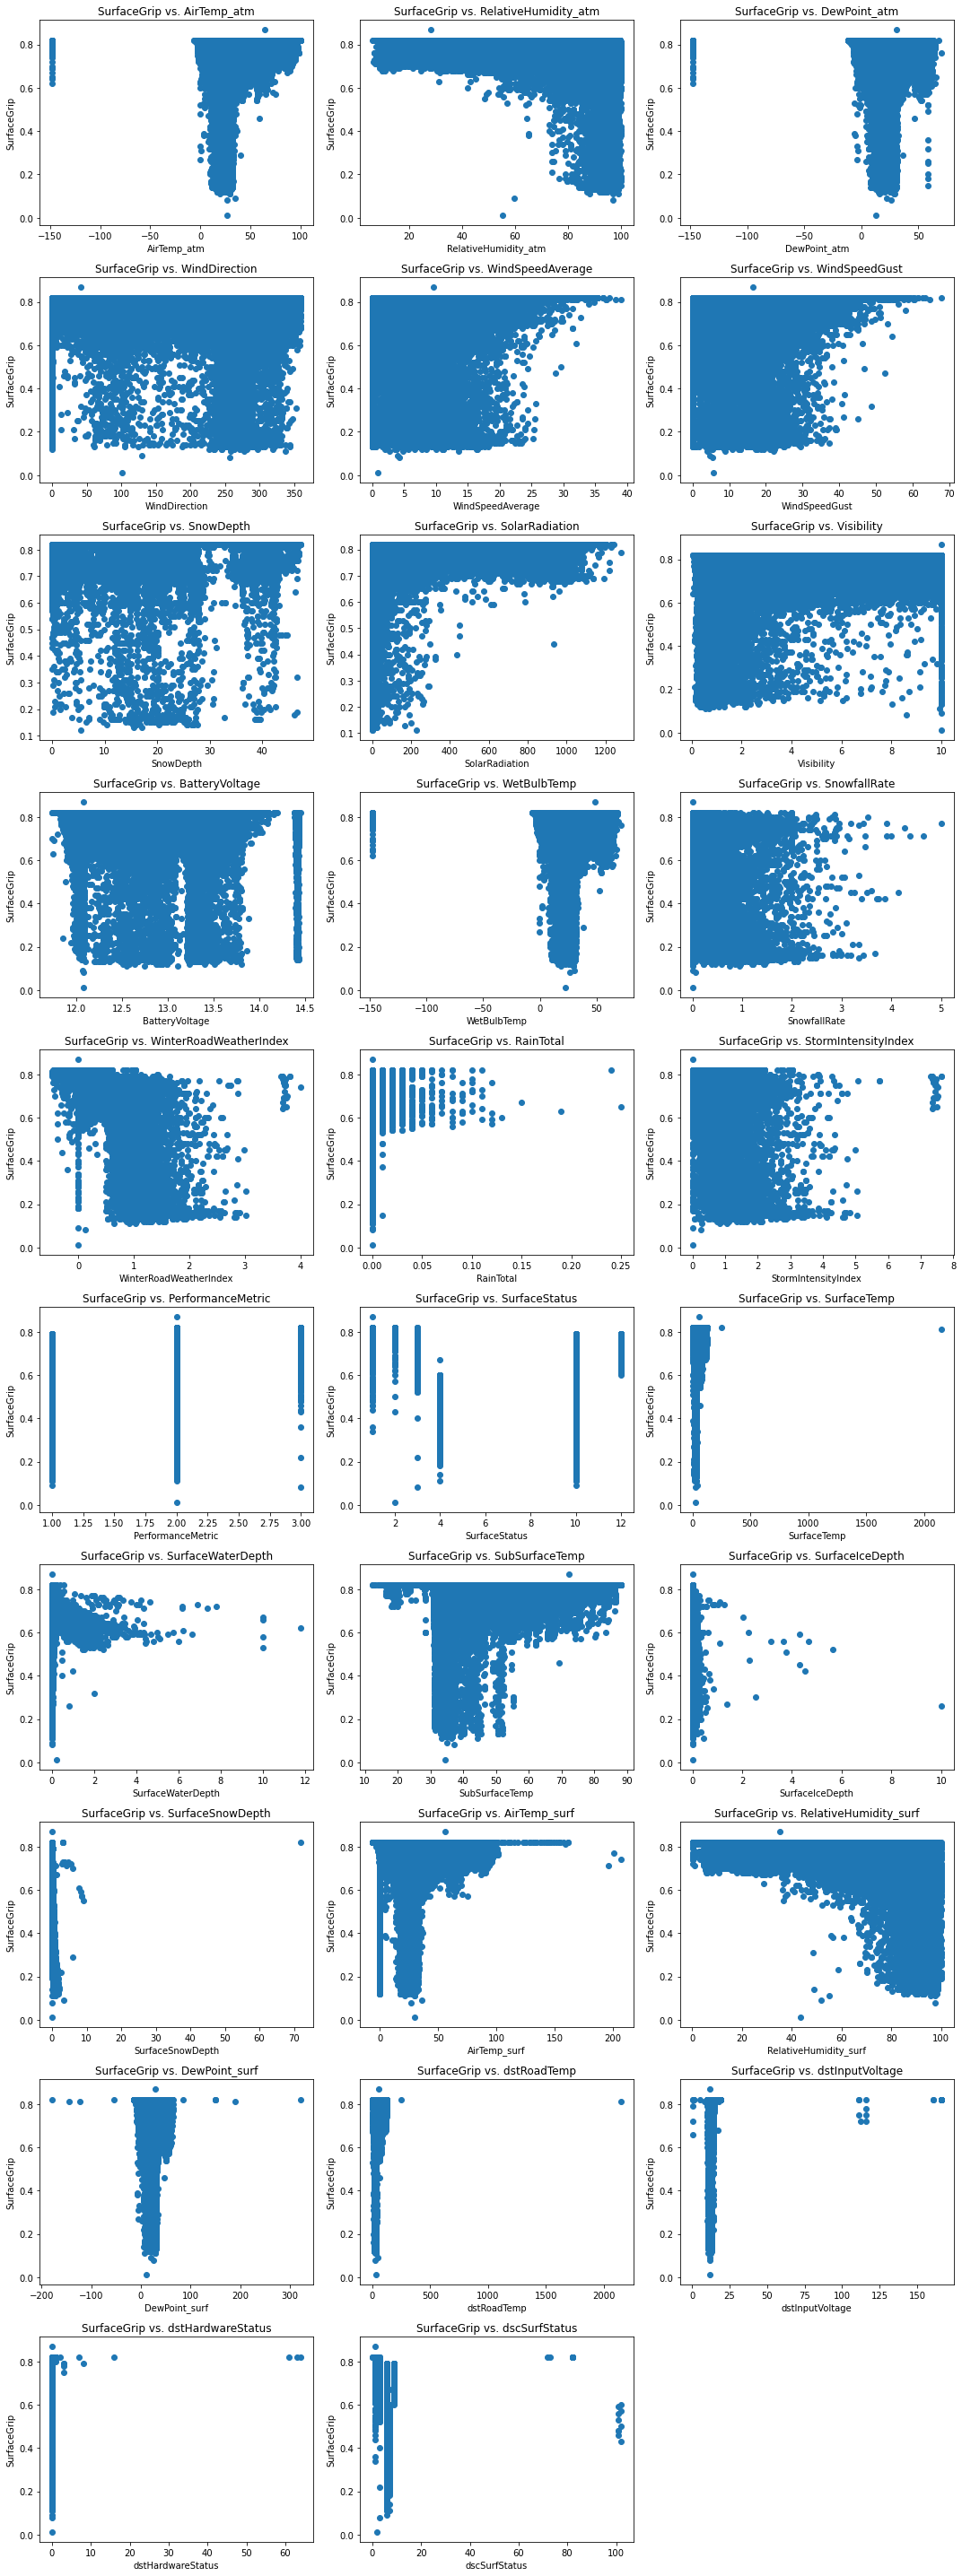

In [21]:
import matplotlib.pyplot as plt

df = df10.copy()

# only pick true numeric (float/int) columns
param_cols = [
    c for c in df.columns
    if df[c].dtype.kind in ('i','f') and c != 'SurfaceGrip'
]

cols_per_row = 3
rows = (len(param_cols) + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*5, rows*4))
axes = axes.flatten()

for ax, col in zip(axes, param_cols):
    ax.scatter(df[col], df['SurfaceGrip'])
    ax.set_xlabel(col)
    ax.set_ylabel('SurfaceGrip')
    ax.set_title(f'SurfaceGrip vs. {col}')

for ax in axes[len(param_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


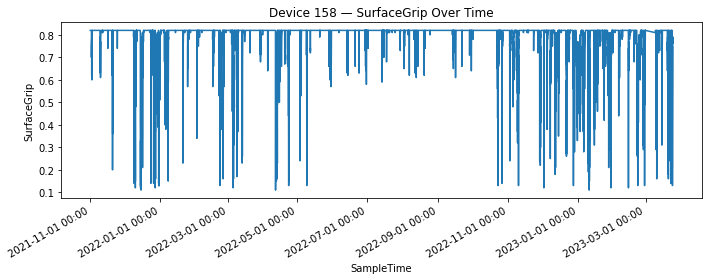

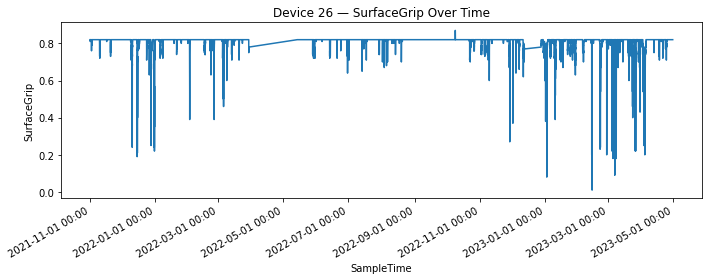

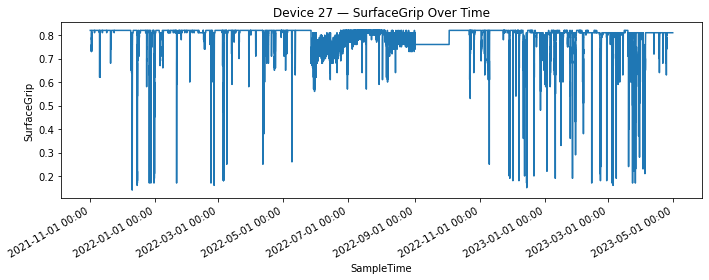

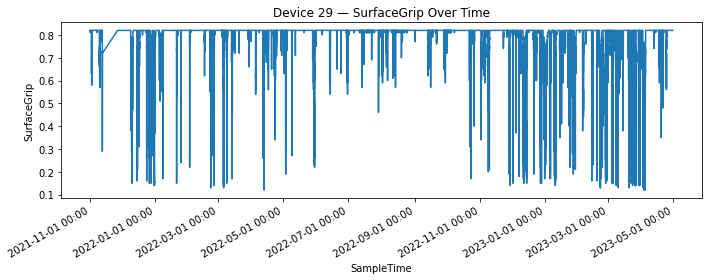

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure SampleTime is datetime
df10['SampleTime'] = pd.to_datetime(df10['SampleTime'])

# Loop through each device and plot its own figure
for device_id in df10['RwisControllerIntId'].unique():
    grp = df10[df10['RwisControllerIntId'] == device_id].sort_values('SampleTime')
    
    plt.figure(figsize=(10, 4))
    plt.plot(grp['SampleTime'], grp['SurfaceGrip'])
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.gcf().autofmt_xdate()
    plt.title(f'Device {device_id} — SurfaceGrip Over Time')
    plt.xlabel('SampleTime')
    plt.ylabel('SurfaceGrip')
    plt.tight_layout()
    plt.show()


Saved combined plot → plots/combined_devices.png


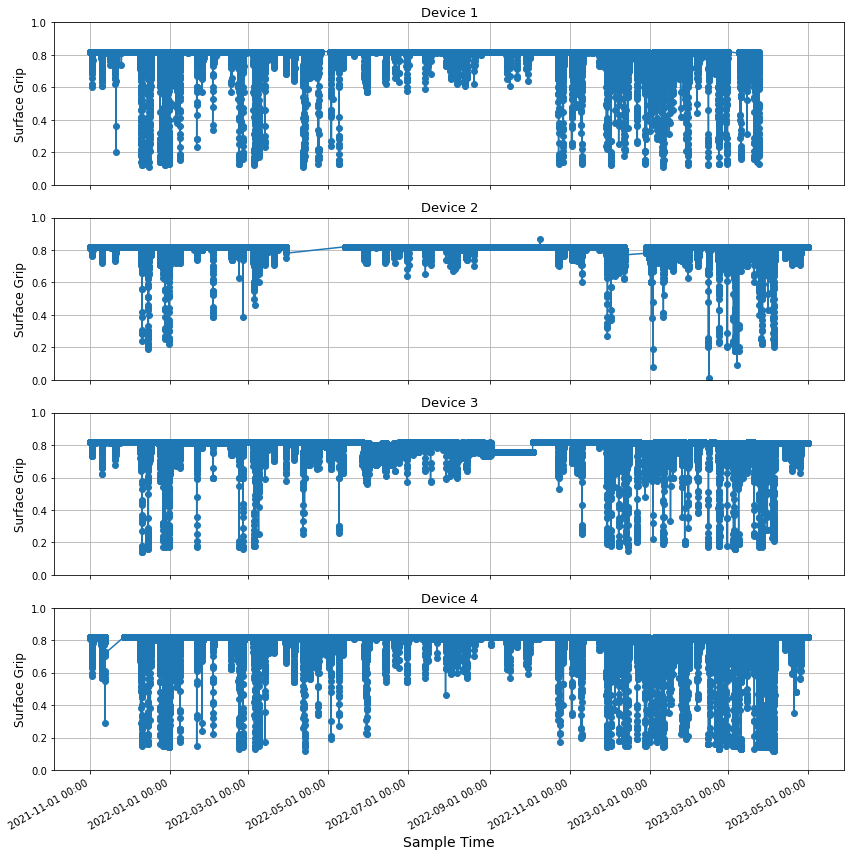

In [23]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure SampleTime is datetime
df10['SampleTime'] = pd.to_datetime(df10['SampleTime'])

# Output directory
out_dir = "plots"
os.makedirs(out_dir, exist_ok=True)

# Turn off interactive mode
plt.ioff()

# Unique devices sorted for consistent ordering
unique_devices = sorted(df10['RwisControllerIntId'].unique())
n_devices = len(unique_devices)

# Create figure with subplots
fig, axes = plt.subplots(n_devices, 1, figsize=(12, 3 * n_devices), sharex=True)

# Ensure axes is iterable
if n_devices == 1:
    axes = [axes]

# Plot each device
for i, (ax, device_id) in enumerate(zip(axes, unique_devices), start=1):
    grp = df10[df10['RwisControllerIntId'] == device_id].sort_values('SampleTime')
    
    ax.plot(grp['SampleTime'], grp['SurfaceGrip'], marker='o', label=f'Device {i}')
    ax.set_ylabel('Surface Grip', fontsize=12)
    ax.set_ylim(0,1)
    ax.set_title(f'Device {i}', fontsize=13)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
#     ax.legend()
    ax.grid(True)

# Set common x-label
axes[-1].set_xlabel('Sample Time', fontsize=14)

# Auto format x-axis date labels
fig.autofmt_xdate()

plt.tight_layout()

# Save to file
combined_fname = os.path.join(out_dir, "combined_devices.png")
fig.savefig(combined_fname, dpi=600)
print(f"Saved combined plot → {combined_fname}")

plt.show()
plt.close(fig)


Saved plot for device 158 → plots/device_158.png


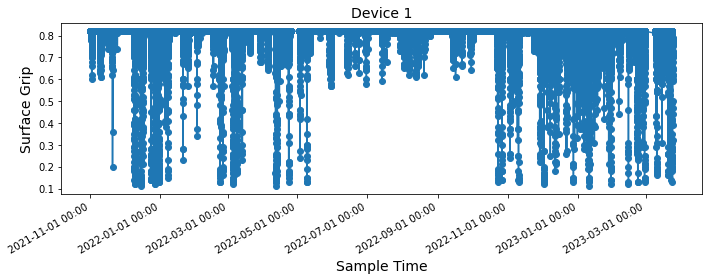

Saved plot for device 26 → plots/device_26.png


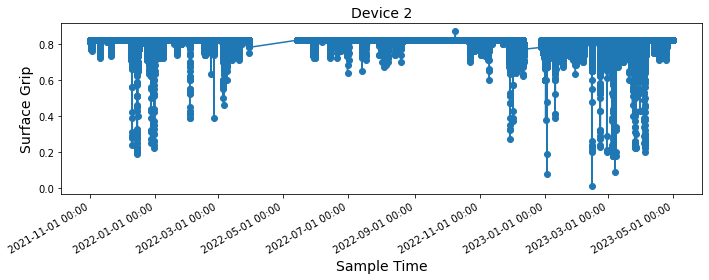

Saved plot for device 27 → plots/device_27.png


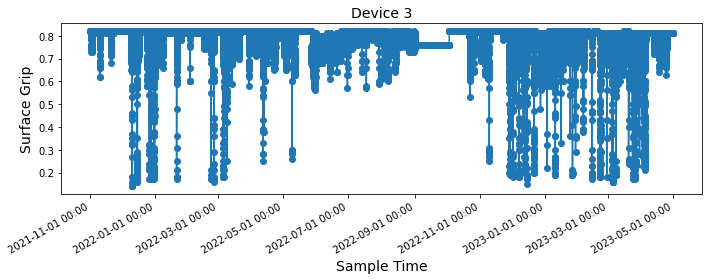

Saved plot for device 29 → plots/device_29.png


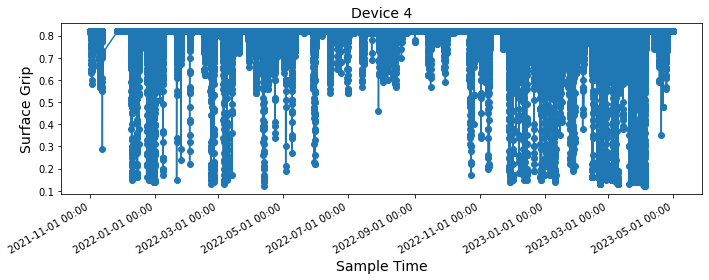

In [24]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure SampleTime is datetime
df10['SampleTime'] = pd.to_datetime(df10['SampleTime'])

# output directory
out_dir = "plots"
os.makedirs(out_dir, exist_ok=True)

# Turn off interactive mode so plt.show() blocks if you still want to see it
plt.ioff()

device_number = 0
for device_id, grp in df10.groupby('RwisControllerIntId'):
    device_number = device_number + 1
    grp = grp.sort_values('SampleTime')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(grp['SampleTime'], grp['SurfaceGrip'], marker='o')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    fig.autofmt_xdate()
    ax.set_title(f'Device {device_number}',fontsize = 14)
    ax.set_xlabel('Sample Time',fontsize = 14)
    ax.set_ylabel('Surface Grip',fontsize = 14)
    plt.tight_layout()
    
    # save to file
    fname = os.path.join(out_dir, f"device_{device_id}.png")
    fig.savefig(fname, dpi=600)
    print(f"Saved plot for device {device_id} → {fname}")
    plt.show()

    
    plt.close(fig)


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    explained_variance_score,
    max_error
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Cell 1: define categorical columns to one-hot encode
cat_cols = [
    'PrecipitationIntensity',
    'PrecipitationType',
    'SurfaceStatusText',
    'dscRoadStatusText'
]

# Cell 2: perform one-hot encoding on df10
df_enc = pd.get_dummies(
    df10,
    columns=cat_cols,
    drop_first=True,
    dummy_na=True
)


unwanted = [
    'SampleTime', 
#     'time_diff',
#     'dscLevelOfGrip',
    #'SurfaceStatusText_unknown', 
    # ... add any other dummy columns or original features here
]

# Method A: drop directly from the DataFrame
df_enc.drop(columns=unwanted, inplace=True)

# Cell 3: select numeric feature columns (exclude target)
features = [
    c for c in df_enc.select_dtypes(include=[np.number]).columns
    if c != 'SurfaceGrip'
]

print("Selected features:", features)

# Cell 4: build modeling DataFrame and drop rows with missing values
df_model = df_enc[features + ['SurfaceGrip']].dropna()
X = df_model[features]
y = df_model['SurfaceGrip']

# Cell 5: train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ------------------------------------------------------#

Selected features: ['AirTemp_atm', 'RelativeHumidity_atm', 'DewPoint_atm', 'WindDirection', 'WindSpeedAverage', 'WindSpeedGust', 'SnowDepth', 'SolarRadiation', 'Visibility', 'BatteryVoltage', 'WetBulbTemp', 'SnowfallRate', 'WinterRoadWeatherIndex', 'RainTotal', 'StormIntensityIndex', 'PerformanceMetric', 'SurfaceStatus', 'SurfaceTemp', 'SurfaceWaterDepth', 'SubSurfaceTemp', 'SurfaceIceDepth', 'SurfaceSnowDepth', 'AirTemp_surf', 'RelativeHumidity_surf', 'DewPoint_surf', 'dstRoadTemp', 'dstInputVoltage', 'dstHardwareStatus', 'dscSurfStatus', 'PrecipitationIntensity_Heavy', 'PrecipitationIntensity_Light', 'PrecipitationIntensity_Moderate', 'PrecipitationIntensity_nan', 'PrecipitationType_Yes', 'PrecipitationType_nan', 'SurfaceStatusText_Dry', 'SurfaceStatusText_Ice', 'SurfaceStatusText_Slushy', 'SurfaceStatusText_Snow', 'SurfaceStatusText_Wet', 'SurfaceStatusText_nan', 'dscRoadStatusText_Dry', 'dscRoadStatusText_Error', 'dscRoadStatusText_Ice', 'dscRoadStatusText_Slush', 'dscRoadStatusTex

## RNN/LSTM


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Cell 1: 按设备+时间排序（保留 SampleTime 列）
df_seq = df10.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)

# Cell 2: 一热编码分类列
cat_cols = [
    'PrecipitationIntensity',
    'PrecipitationType',
    'SurfaceStatusText',
    'dscRoadStatusText'
]
df_seq = pd.get_dummies(
    df_seq,
    columns=cat_cols,
    drop_first=True,
    dummy_na=True
)

# Cell 3: 删除不做建模的列
df_seq.drop(columns=['SampleTime'], inplace=True)

# Cell 4: 定义特征与目标，以及窗口大小
target = 'SurfaceGrip'
features = [c for c in df_seq.columns if c not in ['RwisControllerIntId', target]]
WINDOW_SIZE = 10

# Cell 5: 归一化所有特征
scaler = MinMaxScaler()
df_seq[features] = scaler.fit_transform(df_seq[features])

# Cell 6: 生成时序序列
def create_sequences(data, features, target, window):
    Xs, ys = [], []
    for dev, grp in data.groupby('RwisControllerIntId'):
        arr = grp[features + [target]].values
        for i in range(len(arr) - window):
            Xs.append(arr[i:i+window, :-1])
            ys.append(arr[i+window, -1])
    return np.array(Xs), np.array(ys)

df_seq_clean = df_seq.dropna().reset_index(drop=True)

# Then build sequences off df_seq_clean instead of df_seq
X, y = create_sequences(df_seq_clean, features, 'SurfaceGrip', WINDOW_SIZE)

# X, y = create_sequences(df_seq, features, target, WINDOW_SIZE)
print("X shape:", X.shape)
print("y shape:", y.shape)

# Cell 7: 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



X shape: (55397, 10, 48)
y shape: (55397,)


2025-07-17 14:05:26.643584: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing 

Epoch 72/300
1247/1247 - 5s - loss: 2.2898e-04 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 73/300
1247/1247 - 5s - loss: 2.5278e-04 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 74/300
1247/1247 - 5s - loss: 2.3201e-04 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 75/300
1247/1247 - 5s - loss: 2.1963e-04 - val_loss: 9.1564e-04 - 5s/epoch - 4ms/step
Epoch 76/300
1247/1247 - 5s - loss: 2.1801e-04 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 77/300
1247/1247 - 5s - loss: 2.2779e-04 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 78/300
1247/1247 - 5s - loss: 2.1262e-04 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 79/300
1247/1247 - 6s - loss: 2.0605e-04 - val_loss: 0.0011 - 6s/epoch - 5ms/step
Epoch 80/300
1247/1247 - 6s - loss: 2.0195e-04 - val_loss: 0.0011 - 6s/epoch - 4ms/step
Epoch 81/300
1247/1247 - 5s - loss: 1.9729e-04 - val_loss: 9.7884e-04 - 5s/epoch - 4ms/step
Epoch 82/300
1247/1247 - 5s - loss: 1.9529e-04 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 83/300
1247/1247 -

Epoch 165/300
1247/1247 - 5s - loss: 7.3210e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 166/300
1247/1247 - 5s - loss: 7.3177e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 167/300
1247/1247 - 5s - loss: 7.4894e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 168/300
1247/1247 - 5s - loss: 7.0013e-05 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 169/300
1247/1247 - 5s - loss: 7.8513e-05 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 170/300
1247/1247 - 5s - loss: 7.3736e-05 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 171/300
1247/1247 - 5s - loss: 6.9151e-05 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 172/300
1247/1247 - 5s - loss: 6.8993e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 173/300
1247/1247 - 5s - loss: 7.6266e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 174/300
1247/1247 - 5s - loss: 6.9026e-05 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 175/300
1247/1247 - 5s - loss: 6.7784e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 176/300
1247/12

Epoch 257/300
1247/1247 - 5s - loss: 4.6911e-05 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 258/300
1247/1247 - 5s - loss: 5.0232e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 259/300
1247/1247 - 5s - loss: 4.6966e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 260/300
1247/1247 - 6s - loss: 4.6893e-05 - val_loss: 0.0010 - 6s/epoch - 4ms/step
Epoch 261/300
1247/1247 - 6s - loss: 4.5024e-05 - val_loss: 0.0011 - 6s/epoch - 4ms/step
Epoch 262/300
1247/1247 - 6s - loss: 4.5263e-05 - val_loss: 0.0010 - 6s/epoch - 5ms/step
Epoch 263/300
1247/1247 - 5s - loss: 4.5587e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 264/300
1247/1247 - 5s - loss: 5.0844e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 265/300
1247/1247 - 5s - loss: 4.5325e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 266/300
1247/1247 - 5s - loss: 4.5088e-05 - val_loss: 0.0011 - 5s/epoch - 4ms/step
Epoch 267/300
1247/1247 - 5s - loss: 4.4673e-05 - val_loss: 0.0010 - 5s/epoch - 4ms/step
Epoch 268/300
1247/12

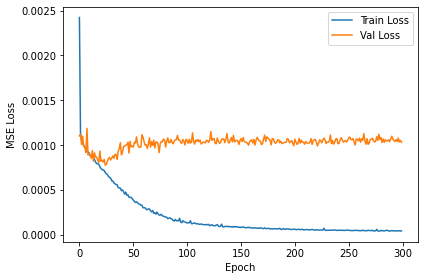

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
347/347 [==============================] - 1s 2ms/step


,Metric,Value
0,MSE,0.0010
1,RMSE,0.0309
2,MAE,0.0078
3,MAPE,1.4855
4,R2,0.7785
5,ExplainedVar,0.7785
6,MaxError,0.5215


In [28]:
import tensorflow as tf
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Cell 7: Build LSTM model
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Cell 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=2
)

# Cell 9: Plot training & validation loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Cell 10: Evaluate on test set
y_pred_rnn = model.predict(X_test).ravel()
mse_rnn = tf.keras.losses.MeanSquaredError()(y_test, y_pred_rnn).numpy()
rmse_rnn = np.sqrt(mse_rnn)
mae_rnn = tf.keras.losses.MeanAbsoluteError()(y_test, y_pred_rnn).numpy()
mape_rnn = tf.keras.losses.MeanAbsolutePercentageError()(y_test, y_pred_rnn).numpy()
r2_rnn = r2_score(y_test, y_pred_rnn)
evs_rnn = explained_variance_score(y_test, y_pred_rnn)
maxe_rnn = max_error(y_test, y_pred_rnn)

# Cell 11: Display metrics
metrics_rnn = pd.DataFrame({
    'Metric': ['MSE','RMSE','MAE','MAPE','R2','ExplainedVar','MaxError'],
    'Value': [mse_rnn, rmse_rnn, mae_rnn, mape_rnn, r2_rnn, evs_rnn, maxe_rnn]
})
display(metrics_rnn.style.format({'Value': '{:.4f}'}))


In [29]:
# 1) 把真实值和预测值放到同一个 DataFrame
eval_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred_rnn
})

# 2) 定义 0.1 间隔的分段
bins = np.arange(0.0, 1.01, 0.1)
labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins)-1)]

# 3) 打标签
eval_df['bin'] = pd.cut(
    eval_df['y_true'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 4) 计算每个区间的样本量和 R²
results = []
for lbl in labels:
    sub = eval_df[eval_df['bin'] == lbl]
    count = len(sub)
    r2_val = r2_score(sub['y_true'], sub['y_pred']) if count >= 2 else np.nan
    results.append({'Interval': lbl, 'Count': count, 'R²': r2_val})

bin_metrics_rnn = pd.DataFrame(results).set_index('Interval')

# 5) 显示每区间 Count 和 R²
display(
    bin_metrics_rnn.style.format({
        'Count': '{:.0f}',
        'R²': '{:.4f}'
    })
)

# 6) 计算并打印平均分段 R²（跳过 NaN）
avg_r2_rnn = bin_metrics_rnn['R²'].mean()
print(f"\nLSTM 平均分段 R²：{avg_r2_rnn:.4f}")

,Count,R²
Interval,,
0.0–0.1,0,nan
0.1–0.2,24,-232.5886
0.2–0.3,28,-43.4583
0.3–0.4,33,-83.6852
0.4–0.5,41,-28.6335
0.5–0.6,62,-20.4852
0.6–0.7,395,-3.7727
0.7–0.8,1160,-2.8870
0.8–0.9,9337,-0.3432



LSTM 平均分段 R²：-51.9817


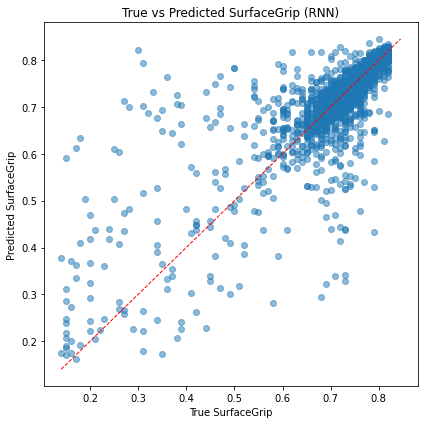

In [30]:
import matplotlib.pyplot as plt

# True vs Predicted for RNN
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rnn, alpha=0.5)
min_val = min(y_test.min(), y_pred_rnn.min())
max_val = max(y_test.max(), y_pred_rnn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
plt.xlabel('True SurfaceGrip')
plt.ylabel('Predicted SurfaceGrip')
plt.title('True vs Predicted SurfaceGrip (RNN)')
plt.tight_layout()
plt.show()


/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:30: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:30: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:30: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:30: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:30: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:30:

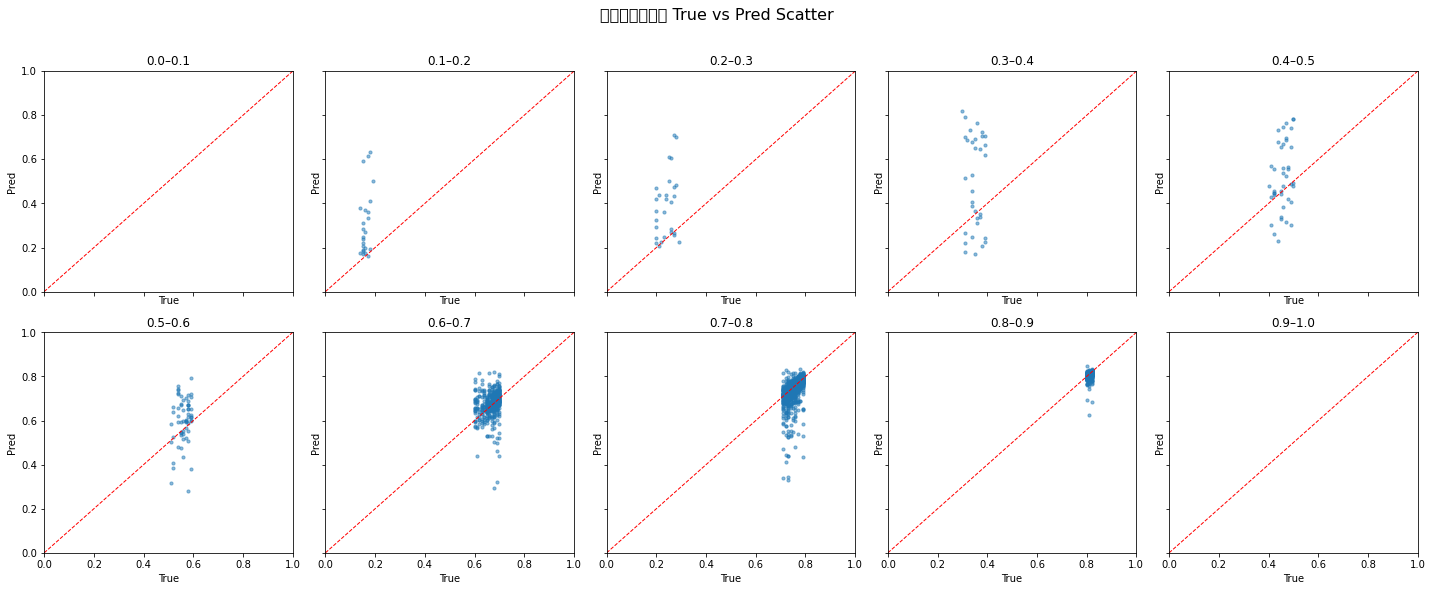

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 先把真实值和预测值合并到一个 DataFrame，并打上 bin 标签
eval_df = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_rnn})
bins = np.arange(0.0, 1.01, 0.1)
labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins)-1)]
eval_df['bin'] = pd.cut(eval_df['y_true'], bins=bins, labels=labels, include_lowest=True)

# 准备画布：2 行 5 列
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lbl in zip(axes, labels):
    sub = eval_df[eval_df['bin'] == lbl]
    ax.scatter(sub['y_true'], sub['y_pred'], alpha=0.5, s=10)
    ax.plot([0,1],[0,1],'r--', lw=1)
    ax.set_title(lbl)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xlabel('True')
    ax.set_ylabel('Pred')

# 隐藏多余的子图（如果有）
for ax in axes[len(labels):]:
    ax.axis('off')

plt.suptitle('按真实值分段的 True vs Pred Scatter', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


总序列数: 291712
常数序列数: 221175 (75.82%)
变化序列数: 70537 (24.18%)


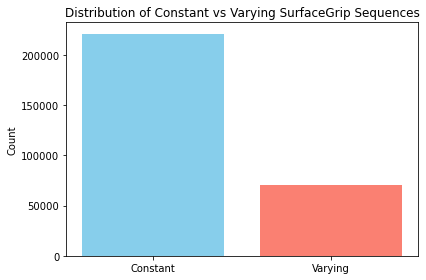

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 假设 df_seq 已经按设备 & 时间排序并包含 'SurfaceGrip' 列
WINDOW_SIZE = 10

total_count = 0
const_count = 0

# 统计每个设备的SurfaceGrip滑窗序列
for dev, grp in df_seq.groupby('RwisControllerIntId'):
    grip = grp['SurfaceGrip'].values
    # 序列长度为 WINDOW_SIZE + 1
    for i in range(len(grip) - WINDOW_SIZE):
        seq = grip[i:i + WINDOW_SIZE + 1]
        total_count += 1
        if np.all(seq == seq[0]):
            const_count += 1

vary_count = total_count - const_count

# 打印统计结果
print(f"总序列数: {total_count}")
print(f"常数序列数: {const_count} ({const_count/total_count:.2%})")
print(f"变化序列数: {vary_count} ({vary_count/total_count:.2%})")

# 绘制分布柱状图
plt.figure(figsize=(6, 4))
labels = ['Constant', 'Varying']
counts = [const_count, vary_count]
plt.bar(labels, counts, color=['skyblue', 'salmon'])
plt.ylabel('Count')
plt.title('Distribution of Constant vs Varying SurfaceGrip Sequences')
plt.tight_layout()
plt.show()


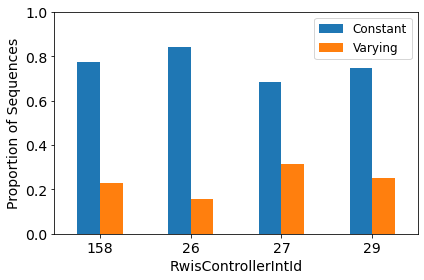

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df10 is sorted by device and time
df_seq = df10.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
WINDOW_SIZE = 10

# Compute constant vs varying counts per device
results = []
for dev, grp in df_seq.groupby('RwisControllerIntId'):
    grips = grp['SurfaceGrip'].values
    total = len(grips) - WINDOW_SIZE
    const = 0
    for i in range(total):
        window = grips[i:i + WINDOW_SIZE + 1]
        if np.all(window == window[0]):
            const += 1
    vary = total - const
    results.append({'device': dev, 'Constant': const, 'Varying': vary})

# Build DataFrame
df_counts = pd.DataFrame(results).set_index('device')
df_props = df_counts.div(df_counts.sum(axis=1), axis=0)

# Plot grouped bar chart of proportions
ax = df_props.plot(kind='bar')
ax.set_xlabel('RwisControllerIntId',fontsize =14)
ax.set_ylabel('Proportion of Sequences',fontsize =14)
# ax.set_title('Constant vs Varying Sequence Proportions by Device')
plt.xticks(rotation=0,fontsize =14)
plt.yticks(fontsize =14)
plt.ylim(0,1)
plt.legend(fontsize =12)
plt.tight_layout()
plt.show()


In [34]:
df10['PrecipitationIntensity'] = df10['PrecipitationIntensity'].fillna('None')
df10['PrecipitationIntensity'].value_counts()

None        266221
Light        22157
Moderate      2416
Heavy          730
Fog            228
Name: PrecipitationIntensity, dtype: int64

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# 1) 预处理 df10：填充降水类别、排序
df_seq = df10.copy()
df_seq['PrecipitationIntensity'] = (
    df_seq['PrecipitationIntensity']
      .fillna('None')
      .str.strip()
      .str.title()
)
df_seq = df_seq.sort_values(['RwisControllerIntId','SampleTime']).reset_index(drop=True)

WINDOW_SIZE = 10

# 2) 收集各类别的序列起点
seqs = {'None': [], 'Light': [], 'Moderate': [], 'Heavy': []}
for dev, grp in df_seq.groupby('RwisControllerIntId'):
    grips = grp['SurfaceGrip'].values
    precs = grp['PrecipitationIntensity'].values
    for i in range(len(grips) - WINDOW_SIZE):
        u = set(precs[i:i + WINDOW_SIZE + 1])
        if u == {'None'}:
            seqs['None'].append((dev, i))
        if 'Light' in u:
            seqs['Light'].append((dev, i))
        if 'Moderate' in u:
            seqs['Moderate'].append((dev, i))
        if 'Heavy' in u:
            seqs['Heavy'].append((dev, i))

# 3) 查看每类序列数量
print("Sequence counts per category:", {k: len(v) for k, v in seqs.items()})

# 4) 序列绘图函数
markers = {'Light': '*', 'Moderate': 'o', 'Heavy': '>'}

def plot_sequence(dev, start,device_id):
    
    grp = df_seq[df_seq['RwisControllerIntId'] == dev].reset_index(drop=True)
    times = grp.loc[start:start + WINDOW_SIZE, 'SampleTime']
    grips = grp.loc[start:start + WINDOW_SIZE, 'SurfaceGrip']
    precs = grp.loc[start:start + WINDOW_SIZE, 'PrecipitationIntensity']
    
    plt.figure(figsize=(8, 4))
    # 底图：黑色折线 + 黑点
    plt.plot(times, grips, '-o', color='black',
             markerfacecolor='black', markeredgecolor='black',
             zorder=1, label='Surface Grip')
    # 覆盖降水标记
    for cat, m in markers.items():
        mask = precs == cat
        if mask.any():
            plt.scatter(times[mask], grips[mask],
                        marker=m, color='blue', s=100,
                        zorder=2, label=cat)
    
    plt.title(f"Device {device_id} | Start {times.iloc[0]}",fontsize=14)
    plt.xlabel('Sample Time',fontsize=14)
    plt.ylabel('Surface Grip',fontsize=14)
    plt.xticks(rotation=45,fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.tight_layout()


Sequence counts per category: {'None': 237153, 'Light': 53320, 'Moderate': 10623, 'Heavy': 3735}


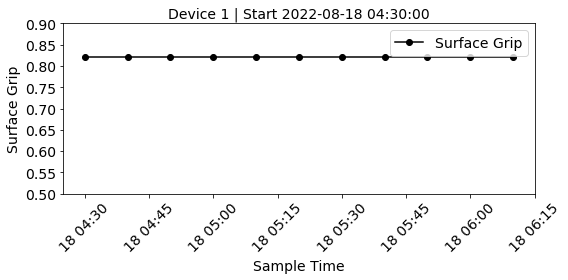

In [36]:
# 5) 分别绘制四张图，不用循环
# No rain
SEED = 1              # choose any integer you like
random.seed(SEED)   
dev_none, start_none = random.choice(seqs['None'])
plot_sequence(dev_none, start_none,device_id=1)
plt.ylim(0.5,0.9)

plt.savefig("No Rain.png", dpi=600)

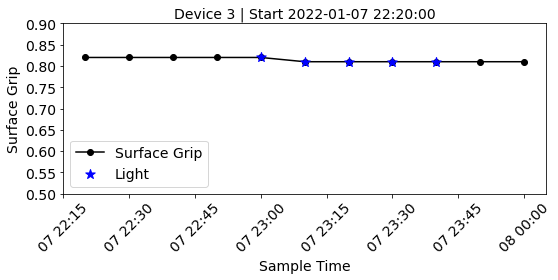

In [37]:
# Light
SEED = 25          # choose any integer you like
random.seed(SEED)  
dev_light, start_light = random.choice(seqs['Light'])
plot_sequence(dev_light, start_light,device_id=3)
plt.ylim(0.5,0.9)
plt.savefig("LightRain.png", dpi=600)

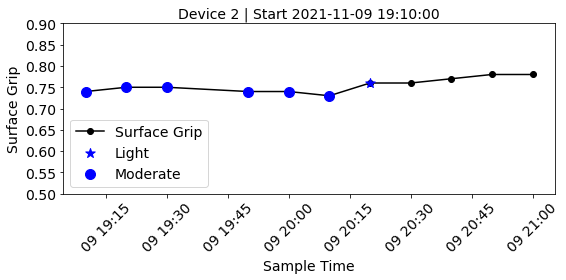

In [38]:
# Moderate
SEED = 1            # choose any integer you like
random.seed(SEED)  
dev_mod, start_mod = random.choice(seqs['Moderate'])
plot_sequence(dev_mod, start_mod,device_id=2)
plt.ylim(0.5,0.9)
plt.savefig("moderate Rain.png", dpi=600)

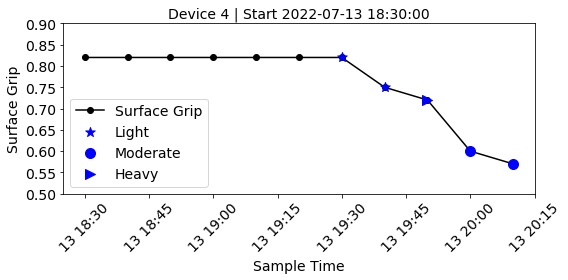

In [39]:
# Heavy
SEED = 2             # choose any integer you like
random.seed(SEED)   
dev_heavy, start_heavy = random.choice(seqs['Heavy'])
plot_sequence(dev_heavy, start_heavy,device_id=4)
plt.ylim(0.5,0.9)
plt.savefig("heavyRain.png", dpi=600)

## prepare data

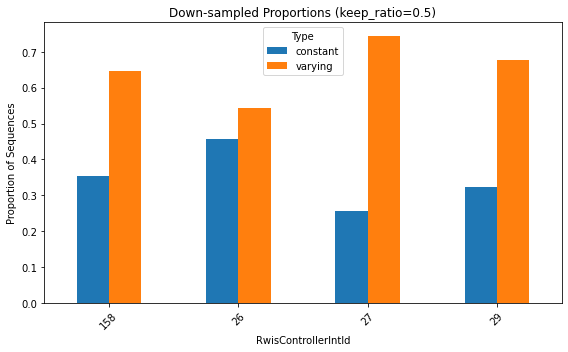

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# ========== User Parameter ==========
keep_ratio = 0.5  # 常数窗口下采样比例（常数窗口数量 = vary_count * keep_ratio）

# ========== Prepare Data ==========
# 假设 df10 已经在环境中，并包含以下列：
# 'RwisControllerIntId', 'SampleTime', 'SurfaceGrip'
df_seq = df10.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)

WINDOW_SIZE = 10

# ========== Collect Windows ==========
const_windows = []
vary_windows = []

for dev, grp in df_seq.groupby('RwisControllerIntId'):
    grips = grp['SurfaceGrip'].values
    for i in range(len(grips) - WINDOW_SIZE):
        window = grips[i:i + WINDOW_SIZE + 1]
        if np.all(window == window[0]):
            const_windows.append((dev, i))
        else:
            vary_windows.append((dev, i))

# ========== Down-sample Constants ==========
n_vary = len(vary_windows)
n_const_keep = int(n_vary * keep_ratio)

random.seed(42)
sampled_const = random.sample(const_windows, min(n_const_keep, len(const_windows)))

# ========== Combine and Shuffle ==========
final_windows = sampled_const + vary_windows
random.shuffle(final_windows)

# ========== Compute Post Down-sample Ratios ==========
results_ds = []
for dev, grp in df_seq.groupby('RwisControllerIntId'):
    const_count = sum(1 for d, i in final_windows if d == dev and (d, i) in sampled_const)
    vary_count = sum(1 for d, i in final_windows if d == dev and (d, i) in vary_windows)
    results_ds.append({'device': dev, 'constant': const_count, 'varying': vary_count})

df_counts_ds = pd.DataFrame(results_ds).set_index('device')
df_props_ds = df_counts_ds.div(df_counts_ds.sum(axis=1), axis=0)

# ========== Plot ==========
ax = df_props_ds.plot(kind='bar', figsize=(8, 5))
ax.set_xlabel('RwisControllerIntId')
ax.set_ylabel('Proportion of Sequences')
ax.set_title(f'Down-sampled Proportions (keep_ratio={keep_ratio})')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.tight_layout()
plt.show()


In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Parameters
WINDOW_SIZE = 10

# 1) Preprocess df10: sort and fill categories (assuming df10 exists)
df_seq = df10.copy()
df_seq['PrecipitationIntensity'] = (
    df_seq['PrecipitationIntensity'].fillna('None').str.strip().str.title()
)
df_seq = df_seq.sort_values(['RwisControllerIntId','SampleTime']).reset_index(drop=True)

# 2) Define feature columns for sequence and tabular
features = [c for c in df_seq.columns
            if c not in ['RwisControllerIntId','SampleTime','SurfaceGrip']]

# 3) Scale features to [0,1]
scaler = MinMaxScaler()
df_seq[features] = scaler.fit_transform(df_seq[features])

# 4) Generate sequences and aligned tabular samples
X_seq, y_seq = [], []
X_tab = []
sequence_indices = []

for dev, grp in df_seq.groupby('RwisControllerIntId'):
    grp = grp.reset_index(drop=True)
    arr = grp[features + ['SurfaceGrip']].values
    for i in range(len(arr) - WINDOW_SIZE):
        # sequence for RNN: WINDOW_SIZE steps of features
        X_seq.append(arr[i:i+WINDOW_SIZE, :-1])
        # target is SurfaceGrip at next step
        y_seq.append(arr[i+WINDOW_SIZE, -1])
        # tabular features: features at that next step
        X_tab.append(arr[i+WINDOW_SIZE, :-1])
        sequence_indices.append((dev, grp.loc[i+WINDOW_SIZE, 'SampleTime']))

X_seq = np.array(X_seq)  # shape (n_samples, WINDOW_SIZE, n_features)
y_seq = np.array(y_seq)  # shape (n_samples,)
X_tab = np.array(X_tab)  # shape (n_samples, n_features)

print("RNN data shape:", X_seq.shape, y_seq.shape)
print("Tabular data shape:", X_tab.shape, y_seq.shape)

# 5) Split both datasets (using same random_state for alignment)
X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = \
    train_test_split(X_seq, X_tab, y_seq, test_size=0.2, random_state=42)

print("Train shapes:", X_seq_train.shape, X_tab_train.shape, y_train.shape)
print("Test shapes:", X_seq_test.shape, X_tab_test.shape, y_test.shape)


ValueError: could not convert string to float: 'None'